In [1]:
import os
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

NUM_RUNS = 5                       
Y_SCALE_FACTOR = 1000000.0         
EPOCHS = 400                       
BATCH_SIZE = 64                    
LR = 0.001                         
MC_SAMPLES = 30                   # MC Dropout 的采样次数，通常 30~100 次即可
DATA_FOLDER = 'grounddata_new/collect_pressure_peak_merged'
OUTPUT_FOLDER = 'predictions_MC'      

case_info_df = pd.read_csv('grounddata_new/case_info.csv')[['id', 'blast', 'bili_height', 'height']]
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

class ImprovedMLP(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedMLP, self).__init__()
        # 在网络中加入 nn.Dropout
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.SiLU(),
            nn.Linear(128, 256), nn.SiLU(),
            
            nn.Linear(256, 128), nn.SiLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 64), nn.SiLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 1),
            nn.Softplus()
        )
    def forward(self, x):
        return self.net(x)

def enable_dropout(model):
    """强制开启模型中的 Dropout 层，而其他层（如 BatchNorm）可以保持 eval 状态"""
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

def mape_loss(pred, true):
    return torch.mean(torch.abs((pred - true) / (true + 1e-5)))

for run_id in range(1, NUM_RUNS + 1):
    print(f"\n{'='*40}")
    print(f"          开始第 {run_id} 次独立实验          ")
    print(f"{'='*40}")
    
    SEED = 42 + run_id
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    
    all_case_data = [] 
    
    for filename in os.listdir(DATA_FOLDER):
        case_path = os.path.join(DATA_FOLDER, filename)
        case_row = case_info_df[case_info_df['id'] == filename]
        if case_row.empty: 
            continue
        
        blast = case_row.iloc[0]['blast']
        b_height = case_row.iloc[0]['bili_height']
        height = case_row.iloc[0]['height']
        
        try:
            points_data = np.loadtxt(case_path)
            if len(points_data.shape) == 1:
                points_data = points_data.reshape(1, -1)
        except Exception:
            continue
        
        case_X = []
        case_y = []
        
        for row in points_data:
            x, y, z, p = row[0], row[1], row[2], row[3] - 101325
            R = np.sqrt(x**2 + y**2 + z**2)
            Z = R / (blast**(1/3)) if blast > 0 else R
            log_Z = np.log(Z + 1e-5)
            inv_Z = 1.0 / (Z + 1e-5)
            case_X.append([x, y, z, blast, b_height, height, R, Z, log_Z, inv_Z])
            case_y.append(p)
        
        if len(case_X) > 0:
            all_case_data.append({
                'case_file': filename,
                'X': np.array(case_X),
                'y': np.array(case_y).reshape(-1, 1),
                'raw_points': points_data
            })

    n_total_files = len(all_case_data)
    n_test_files = max(1, int(n_total_files * 0.2))  
    
    shuffled_indices = np.random.permutation(n_total_files)
    test_indices = shuffled_indices[:n_test_files]
    train_indices = shuffled_indices[n_test_files:]
    
    train_cases = [all_case_data[i] for i in train_indices]
    test_cases = [all_case_data[i] for i in test_indices]
    for case in train_cases: case['split'] = 'train'
    for case in test_cases: case['split'] = 'test' 
    
    X_train = np.vstack([case['X'] for case in train_cases])
    y_train = np.vstack([case['y'] for case in train_cases])
    X_test = np.vstack([case['X'] for case in test_cases])
    y_test = np.vstack([case['y'] for case in test_cases])
    
    scaler_X = StandardScaler()
    X_train_norm = scaler_X.fit_transform(X_train)
    X_test_norm = scaler_X.transform(X_test)
    joblib.dump(scaler_X, f'scaler_X_{run_id}.pkl')
    
    y_train_scaled = y_train / Y_SCALE_FACTOR
    y_test_scaled = y_test / Y_SCALE_FACTOR
    
    train_dataset = TensorDataset(torch.tensor(X_train_norm, dtype=torch.float32), torch.tensor(y_train_scaled, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test_norm, dtype=torch.float32), torch.tensor(y_test_scaled, dtype=torch.float32))
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = ImprovedMLP(input_dim=10)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    best_val_loss = float('inf')
    model_save_path = f'model_{run_id}.pth'
    
    print(f"|-- 数据准备完毕：训练集算例 {len(train_cases)}个，总体测点 {len(X_train)}个 --|")
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = mape_loss(pred, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        train_loss /= len(train_loader)
        
        if (epoch + 1) % 20 == 0:
            model.eval()
            # 验证阶段也应该开启 MC Dropout 才能保证最优权重的选择符合不确定性评估
            enable_dropout(model) 
            val_loss = 0
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    # 验证时可以简单进行一次或多次采样，这里采用单次近似以保证速度，也可以写循环多采样
                    val_loss += mape_loss(model(batch_X), batch_y).item()
            val_loss /= len(test_loader)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), model_save_path)
                
    print(f"-> 第 {run_id} 次训练结束，已保存权重文件: {model_save_path}")
    
    model.load_state_dict(torch.load(model_save_path))
    model.eval()
    enable_dropout(model) # 关键：在推理保存时，强制激活 Dropout 层
    
    run_output_dir = os.path.join(OUTPUT_FOLDER, f'run_{run_id}')
    train_dir = os.path.join(run_output_dir, 'train')
    test_dir = os.path.join(run_output_dir, 'test')
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    
    with torch.no_grad():
        for case in all_case_data:
            case_name = case['case_file']
            case_X = case['X']
            raw_points = case['raw_points']  
            
            case_X_norm = scaler_X.transform(case_X)
            case_X_tensor = torch.tensor(case_X_norm, dtype=torch.float32)
            
            # 进行 MC_SAMPLES 次独立前向传播
            case_preds_list = []
            for _ in range(MC_SAMPLES):
                preds_scaled = model(case_X_tensor).numpy() # 每次因为丢弃的神经元不同，结果不同
                preds_unscaled = (preds_scaled * Y_SCALE_FACTOR) + 101325 # 还原回真实物理尺度
                case_preds_list.append(preds_unscaled)
            
            # 拼接结果，形状转换为 (测点数, MC_SAMPLES)
            case_preds_array = np.hstack(case_preds_list) 
            
            # 计算每个测点在多次预测下的平均值(Mean)和方差(Variance)
            preds_mean = np.mean(case_preds_array, axis=1)
            preds_var = np.var(case_preds_array, axis=1)
            
            target_dir = train_dir if case.get('split') == 'train' else test_dir
            output_filepath = os.path.join(target_dir, case_name)
            with open(output_filepath, 'w', encoding='utf-8') as f:
                for i in range(len(raw_points)):
                    x = raw_points[i, 0]
                    y = raw_points[i, 1]
                    z = raw_points[i, 2]
                    p_mean = preds_mean[i]
                    p_var = preds_var[i]
                    # 修改保存格式：x y z 均值 方差
                    f.write(f"{x} {y} {z} {p_mean:.4f} {p_var:.4f}\n")
                    
    print(f"-> 第 {run_id} 次实验彻底闭环（包含MC不确定性度量）！\n")

/opt/conda/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



          开始第 1 次独立实验          
|-- 数据准备完毕：训练集算例 32个，总体测点 13312个 --|
-> 第 1 次训练结束，已保存权重文件: model_1.pth
-> 第 1 次实验彻底闭环（包含MC不确定性度量）！


          开始第 2 次独立实验          
|-- 数据准备完毕：训练集算例 32个，总体测点 13930个 --|
-> 第 2 次训练结束，已保存权重文件: model_2.pth
-> 第 2 次实验彻底闭环（包含MC不确定性度量）！


          开始第 3 次独立实验          
|-- 数据准备完毕：训练集算例 32个，总体测点 13094个 --|
-> 第 3 次训练结束，已保存权重文件: model_3.pth
-> 第 3 次实验彻底闭环（包含MC不确定性度量）！


          开始第 4 次独立实验          
|-- 数据准备完毕：训练集算例 32个，总体测点 12846个 --|
-> 第 4 次训练结束，已保存权重文件: model_4.pth
-> 第 4 次实验彻底闭环（包含MC不确定性度量）！


          开始第 5 次独立实验          
|-- 数据准备完毕：训练集算例 32个，总体测点 13368个 --|
-> 第 5 次训练结束，已保存权重文件: model_5.pth
-> 第 5 次实验彻底闭环（包含MC不确定性度量）！



In [19]:
import os
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 解决matplotlib中文显示问题（可选，如果标签用英文可以注释掉）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def load_data(pred_dir, true_dir):
    """
    加载指定预测文件夹和真实文件夹中的对应数据
    """
    all_data = []
    
    # 遍历预测文件夹中的所有算例
    for filename in os.listdir(pred_dir):
        pred_path = os.path.join(pred_dir, filename)
        true_path = os.path.join(true_dir, filename)
        
        if not os.path.exists(true_path):
            print(f"警告: 找不到对应的真实数据文件 {filename}，已跳过。")
            continue
            
        # 读取预测数据 (x, y, z, mean, var)
        pred_data = np.loadtxt(pred_path)
        if len(pred_data.shape) == 1:
            pred_data = pred_data.reshape(1, -1)
            
        # 读取真实数据 (x, y, z, p_true) 
        # 顺便兼容你之前代码中减去大气压或保留原样的情况，假设最后一列为总压强 p
        true_data = np.loadtxt(true_path)
        if len(true_data.shape) == 1:
            true_data = true_data.reshape(1, -1)
            
        # 计算测点到爆源(0,0,0)的距离R
        x, y, z = pred_data[:, 0], pred_data[:, 1], pred_data[:, 2]
        R = np.sqrt(x**2 + y**2 + z**2)
        
        p_mean = pred_data[:, 3]-101325
        p_var = pred_data[:, 4]
        p_std = np.sqrt(p_var)
        
        # 95% 置信区间上下界
        lower_bound = p_mean - 1.96 * p_std
        upper_bound = p_mean + 1.96 * p_std
        
        p_true = true_data[:, 3]-101325 # 假设真实数据的第四列是压强P
        
        case_df = pd.DataFrame({
            'R': R,
            'p_true': p_true,
            'p_mean': p_mean,
            'lower': lower_bound,
            'upper': upper_bound,
            'case_name': filename
        })
        all_data.append(case_df)
        
    return all_data

def calculate_metrics(df_all):
    """
    计算 PICP 和 MPIW / NMPIW
    """
    y_true = df_all['p_true'].values
    y_mean = df_all['p_mean'].values
    lower = df_all['lower'].values
    upper = df_all['upper'].values
    
    # 1. PICP: 真实值落入置信区间的比例
    in_interval = (y_true >= lower) & (y_true <= upper)
    picp = np.mean(in_interval)
    
    # 2. MPIW: 平均区间宽度
    widths = upper - lower
    mpiw = np.mean(widths)
    
    # 3. NMPIW: 归一化区间宽度（用真实值的极差归一化，更具可比性）
    y_range = np.max(y_true) - np.min(y_true)
    nmpiw = mpiw / (y_range + 1e-5)
    
    print("\n" + "="*40)
    print("          不确定性量化指标评估          ")
    print("="*40)
    print(f"总评估测点数 : {len(df_all)}")
    print(f"PICP (95% 置信区间覆盖率) : {picp * 100:.2f}%")
    print(f"MPIW (平均预测区间宽度)   : {mpiw:.2f} Pa")
    print(f"NMPIW (归一化区间宽度)    : {nmpiw * 100:.2f}%")
    print("="*40 + "\n")

def plot_by_cases(all_cases_list, save_dir):
    """
    维度一：对各个算例单独绘图（横坐标为到爆源距离R）
    """
    case_plot_dir = os.path.join(save_dir, "individual_cases")
    os.makedirs(case_plot_dir, exist_ok=True)
    
    for df in all_cases_list:
        case_name = df['case_name'].iloc[0]
        # 按距离排序便于线图绘制
        df_sorted = df.sort_values(by='R')
        
        plt.figure(figsize=(10, 6))
        plt.plot(df_sorted['R'], df_sorted['p_true'], 'k_--', label='True', alpha=0.7)
        plt.plot(df_sorted['R'], df_sorted['p_mean'], 'r-', label='Pred', linewidth=2)
        plt.fill_between(df_sorted['R'], df_sorted['lower'], df_sorted['upper'], 
                         color='red', alpha=0.15, label='95% confidence interval')
        
#         plt.title(f"算例不确定性量化分析 - {case_name}")
        plt.xlabel('Distance (m)')
        plt.ylabel("Overpresure Peak(Pa)")
        plt.legend(loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        
        # 替换掉文件名中的非法字符
        safe_filename = case_name.replace('.', '_') + "_uq.png"
        plt.savefig(os.path.join(case_plot_dir, safe_filename), dpi=300, bbox_inches='tight')
        plt.close()
    print(f"-> 所有单算例可视化图片已保存至: {case_plot_dir}")

def plot_all_combined(df_all, save_dir):
    """
    维度二：对所有算例总体绘图（横坐标按真实超压幅值从小到大排序）
    """
    # 按照真实值从小到大排序
    df_sorted = df_all.sort_values(by='p_true').reset_index(drop=True)
    
    plt.figure(figsize=(15, 7))
    
    # 测点较多时，使用 scatter 和 fill_between 结合展现
    x_axis = np.arange(len(df_sorted))
    
    plt.fill_between(x_axis, df_sorted['lower'], df_sorted['upper'], 
                     color='orange', alpha=0.25, label='95% confidence interval')
    plt.plot(x_axis, df_sorted['p_mean'], 'g-', label='Pred', linewidth=1.5)
    plt.scatter(x_axis, df_sorted['p_true'], color='black', s=2, label='True', alpha=0.6)
    
#     plt.title("全体测点不确定性量化分析 (按超压幅值排序)")
    plt.xlabel("POI")
    plt.ylabel("Overpressure Peak(Pa)")
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.5)
    
    save_path = os.path.join(save_dir, "all_cases_combined_uq.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"-> 全体算例聚合可视化图片已保存至: {save_path}")

if __name__ == '__main__':
    # ------------------ 在这里直接手动配置你的路径 ------------------
    PRED_DIR = 'predictions_MC/run_1/test'
    TRUE_DIR = 'grounddata_new/collect_pressure_peak_merged'
    SAVE_DIR = 'uq_results_visual/run1'
    # -------------------------------------------------------------
    
    os.makedirs(SAVE_DIR, exist_ok=True)
    
    # 2. 加载数据
    print("正在读取并匹配预测与真实数据...")
    cases_list = load_data(PRED_DIR, TRUE_DIR)
    
    if not cases_list:
        print("未找到有效的数据对，请检查路径是否正确。")
    else:
        df_all_combined = pd.concat(cases_list, ignore_index=True)
        
        # 3. 计算指标
        calculate_metrics(df_all_combined)
        
        # 4. 绘图与保存
        print("正在绘制各个算例的距离分布不确定性图...")
        plot_by_cases(cases_list, SAVE_DIR)
        
        print("正在绘制全测点幅值排序不确定性图...")
        plot_all_combined(df_all_combined, SAVE_DIR)
        
        print("\n所有评估与可视化任务已顺利完成！")

正在读取并匹配预测与真实数据...
警告: 找不到对应的真实数据文件 .ipynb_checkpoints，已跳过。

          不确定性量化指标评估          
总评估测点数 : 2891
PICP (95% 置信区间覆盖率) : 80.25%
MPIW (平均预测区间宽度)   : 80440.66 Pa
NMPIW (归一化区间宽度)    : 0.90%

正在绘制各个算例的距离分布不确定性图...
-> 所有单算例可视化图片已保存至: uq_results_visual/run1/individual_cases
正在绘制全测点幅值排序不确定性图...
-> 全体算例聚合可视化图片已保存至: uq_results_visual/run1/all_cases_combined_uq.png

所有评估与可视化任务已顺利完成！


In [7]:
import os
import numpy as np
import pandas as pd

def calculate_mape_metrics(pred_dir, true_dir):
    """
    读取保存的预测结果和真实结果，计算整体和单算例的 MAPE
    """
    all_case_results = []
    
    total_true_abs = []
    total_pred_abs = []
    total_true_over = []
    total_pred_over = []
    
    # 遍历预测文件夹
    for filename in sorted(os.listdir(pred_dir)):
        if filename.startswith('.'):
            continue
            
        pred_path = os.path.join(pred_dir, filename)
        true_path = os.path.join(true_dir, filename)
        
        if not os.path.exists(true_path):
            continue
            
        # 1. 读取数据
        # 预测文件格式: x, y, z, p_mean(绝对压强), p_var
        pred_data = np.loadtxt(pred_path)
        if len(pred_data.shape) == 1:
            pred_data = pred_data.reshape(1, -1)
            
        # 真实文件格式: x, y, z, p_true(绝对压强)
        true_data = np.loadtxt(true_path)
        if len(true_data.shape) == 1:
            true_data = true_data.reshape(1, -1)
            
        # 2. 提取绝对压强 (Absolute Pressure)
        y_true_abs = true_data[:, 3]
        y_pred_abs = pred_data[:, 3] # 保存文件中的第4列是多次MC采样的均值
        
        # 3. 计算超压峰值 (Overpressure)
        y_true_over = y_true_abs - 101325
        y_pred_over = y_pred_abs - 101325
        
        # 4. 计算当前算例单文件的 MAPE
        # 绝对压强 MAPE
        case_mape_abs = np.mean(np.abs((y_pred_abs - y_true_abs) / y_true_abs)) * 100
        # 超压峰值 MAPE (加入 1e-5 稳定项防止远处低压测点分母溢出)
        case_mape_over = np.mean(np.abs((y_pred_over - y_true_over) / (y_true_over + 1e-5))) * 100
        
        all_case_results.append({
            '算例名称': filename,
            '测点数量': len(y_true_abs),
            '绝对压强 MAPE (%)': f"{case_mape_abs:.3f}%",
            '超压峰值 MAPE (%)': f"{case_mape_over:.3f}%"
        })
        
        # 收集用于计算全局总 MAPE 的数据
        total_true_abs.extend(y_true_abs)
        total_pred_abs.extend(y_pred_abs)
        total_true_over.extend(y_true_over)
        total_pred_over.extend(y_pred_over)
        
    # 5. 计算全测试集总体的全局 MAPE
    total_true_abs = np.array(total_true_abs)
    total_pred_abs = np.array(total_pred_abs)
    total_true_over = np.array(total_true_over)
    total_pred_over = np.array(total_pred_over)
    
    global_mape_abs = np.mean(np.abs((total_pred_abs - total_true_abs) / total_true_abs)) * 100
    global_mape_over = np.mean(np.abs((total_pred_over - total_true_over) / (total_true_over + 1e-5))) * 100
    
    # 6. 打印精美报告
    print("\n" + "="*50)
    print("          模型确定性预测精度评估 (MAPE)          ")
    print("="*50)
    print(f"测试集总计评估点数 : {len(total_true_abs)}")
    print(f"★ 全局绝对压强总 MAPE : {global_mape_abs:.3f}%")
    print(f"★ 全局超压峰值总 MAPE : {global_mape_over:.3f}%")
    print("="*50)
    
    # 转换为 DataFrame 方便展示
    df_report = pd.DataFrame(all_case_results)
    print("\n[各个算例详细误差清单]:")
    print(df_report.to_string(index=False))
    
    return df_report

if __name__ == '__main__':
    # 填入你的文件夹路径
    PRED_DIR = 'predictions_MC/run_1/test'  
    TRUE_DIR = 'grounddata_new/collect_pressure_peak_merged'
    
    df_res = calculate_mape_metrics(PRED_DIR, TRUE_DIR)


          模型确定性预测精度评估 (MAPE)          
测试集总计评估点数 : 2891
★ 全局绝对压强总 MAPE : 2.353%
★ 全局超压峰值总 MAPE : 18.070%

[各个算例详细误差清单]:
   算例名称  测点数量 绝对压强 MAPE (%) 超压峰值 MAPE (%)
value14   301        1.710%       35.288%
value18   495        1.331%        7.464%
value26   551        3.601%       10.912%
value31   551        3.656%       11.831%
value36   551        1.923%        9.230%
 value5   221        0.506%       23.771%
 value6   221        2.073%       68.116%


Loading and aligning test case data with Scaled Distance mapping...
Alignment successful! Total analyzed gauge points: 2891
Plotting uncertainty analysis with pure matplotlib...


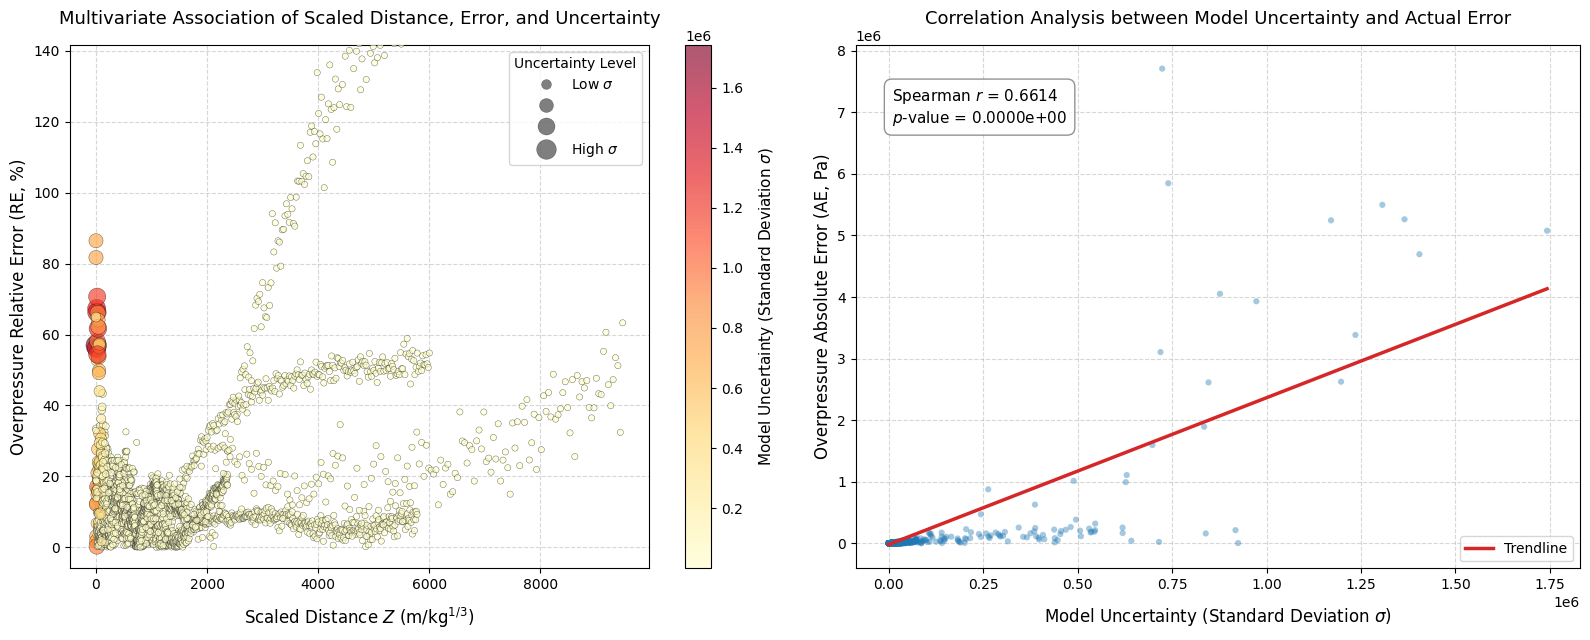

In [8]:
#############################################
##########进行如何分区域预测分析###############
#############################################
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Optimize plot settings for English presentation
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False

def load_aligned_data(pred_dir, true_dir, case_info_path):
    """
    Aligns and reads predicted data and ground truth data, maps the charge mass (blast) 
    from case_info.csv, and computes the Scaled Distance (Z) and error metrics.
    """
    # Load case info to map 'filename/id' to 'blast'
    if not os.path.exists(case_info_path):
        raise FileNotFoundError(f"Case info file not found at: {case_info_path}")
    
    case_info_df = pd.read_csv(case_info_path)[['id', 'blast']]
    # Create a quick-lookup dictionary: { 'filename': blast_value }
    blast_dict = dict(zip(case_info_df['id'], case_info_df['blast']))

    all_points = []
    
    for filename in sorted(os.listdir(pred_dir)):
        if filename.startswith('.'):
            continue
            
        pred_path = os.path.join(pred_dir, filename)
        true_path = os.path.join(true_dir, filename)
        
        if not os.path.exists(true_path):
            continue
            
        # Fetch blast value for the current case file
        blast = blast_dict.get(filename, 0.0)
        
        # Read predicted data (x, y, z, p_mean_abs, p_var)
        pred_data = np.loadtxt(pred_path)
        if len(pred_data.shape) == 1:
            pred_data = pred_data.reshape(1, -1)
            
        # Read ground truth data (x, y, z, p_true_abs)
        true_data = np.loadtxt(true_path)
        if len(true_data.shape) == 1:
            true_data = true_data.reshape(1, -1)
            
        # Safety check for shape alignment
        if pred_data.shape[0] != true_data.shape[0]:
            continue
            
        # Extract physical quantities
        x, y, z = true_data[:, 0], true_data[:, 1], true_data[:, 2]
        p_true_abs = true_data[:, 3]
        p_pred_abs = pred_data[:, 3]
        p_var = pred_data[:, 4]  # Variance from MC Dropout
        
        # Calculate overpressure peak
        p_true_over = p_true_abs - 101325
        p_pred_over = p_pred_abs - 101325
        
        # Compute pointwise metrics
        R = np.sqrt(x**2 + y**2 + z**2)               # Blast distance
        
        # Compute Scaled Distance Z matching your training logic
        Z_scaled = R / (blast**(1/3)) if blast > 0 else R
        
        ae_over = np.abs(p_pred_over - p_true_over)   # Absolute Error (AE)
        re_over = ae_over / (p_true_over + 1e-5)      # Relative Error (RE)
        std_dev = np.sqrt(p_var)                      # Standard Deviation (Uncertainty)
        
        for i in range(len(R)):
            all_points.append({
                'Z': Z_scaled[i],
                'ae_over': ae_over[i],
                're_over': re_over[i],
                'std_dev': std_dev[i]
            })
            
    return pd.DataFrame(all_points)

def plot_uncertainty_analysis_pure_plt(df):
    """
    Plots the bivariate scatter-bubble chart (Z vs RE) and correlation regression line
    using pure matplotlib for restricted online environments.
    """
    if df.empty:
        print("Error: No valid data collected. Please check your directory paths.")
        return

    # Create figure canvas
    fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), dpi=100)
    
    # Configure clean background grid
    for ax in axes:
        ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    
    # --------- Left Plot: Scaled Distance vs Overpressure RE (Bubble = Uncertainty) ---------
    # Filter out extreme outliers (top 2%) of RE to keep the plot visually well-scaled
    v_max_re = np.percentile(df['re_over'], 98) 
    
    # Map standard deviation (std_dev) linearly to bubble sizes [20, 220]
    min_size, max_size = 20, 220
    std_min, std_max = df['std_dev'].min(), df['std_dev'].max()
    size_scale = (df['std_dev'] - std_min) / (std_max - std_min + 1e-8)
    sizes = min_size + size_scale * (max_size - min_size)

    scatter1 = axes[0].scatter(
        df['Z'], 
        df['re_over'] * 100,  # Convert to percentage
        s=sizes, 
        c=df['std_dev'], 
        cmap='YlOrRd', 
        alpha=0.65, 
        edgecolors='black', 
        linewidths=0.3,
        zorder=3
    )
    
    axes[0].set_xlabel('Scaled Distance $Z$ ($\mathrm{m/kg}^{1/3}$)', fontsize=12, labelpad=10)
    axes[0].set_ylabel('Overpressure Relative Error (RE, %)', fontsize=12)
    axes[0].set_title('Multivariate Association of Scaled Distance, Error, and Uncertainty', fontsize=13, pad=15)
    axes[0].set_ylim(-v_max_re * 5, v_max_re * 120)
    
    # Colorbar configuration
    cbar1 = fig.colorbar(scatter1, ax=axes[0])
    cbar1.set_label('Model Uncertainty (Standard Deviation $\sigma$)', fontsize=11, labelpad=10)
    
    # Generate bubble size legends automatically
    handles, labels = scatter1.legend_elements(prop="sizes", alpha=0.5, num=4)
    legend_labels = ["Low $\sigma$", "", "", "High $\sigma$"]
    axes[0].legend(handles, legend_labels, loc="upper right", title="Uncertainty Level")

    # --------- Right Plot: Uncertainty vs Overpressure AE (Correlation Diagnostic) ---------
    # 1. Base Scatter Points
    axes[1].scatter(
        df['std_dev'], 
        df['ae_over'], 
        alpha=0.4, 
        color='#1f77b4', 
        s=20,
        edgecolors='none',
        zorder=3
    )
    
    # 2. Linear Regression Trendline (y = kx + b) via NumPy
    x_arr = df['std_dev'].values
    y_arr = df['ae_over'].values
    if len(x_arr) > 1:
        k, b = np.polyfit(x_arr, y_arr, 1)
        x_trend = np.linspace(x_arr.min(), x_arr.max(), 100)
        y_trend = k * x_trend + b
        axes[1].plot(x_trend, y_trend, color='#d62728', linewidth=2.5, label='Trendline', zorder=4)
        axes[1].legend(loc="lower right")

    # 3. Spearman Rank Correlation Calculation
    corr_coef, p_value = spearmanr(df['std_dev'], df['ae_over'])
    
    axes[1].set_xlabel('Model Uncertainty (Standard Deviation $\sigma$)', fontsize=12, labelpad=10)
    axes[1].set_ylabel('Overpressure Absolute Error (AE, Pa)', fontsize=12)
    axes[1].set_title('Correlation Analysis between Model Uncertainty and Actual Error', fontsize=13, pad=15)
    
    # Annotated statistics text box
    text_str = f"Spearman $r$ = {corr_coef:.4f}\n$p$-value = {p_value:.4e}"
    axes[1].text(
        0.05, 0.92, text_str, 
        transform=axes[1].transAxes, 
        fontsize=11,
        verticalalignment='top', 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray'),
        zorder=5
    )

    plt.tight_layout()
    plt.savefig('uq_results_visual/run1/MC_Dropout_Uncertainty_Analysis_bili_distance.png', dpi=300, bbox_inches='tight')
    plt.show()

# ------------------ Execution Block ------------------
if __name__ == '__main__':
    PRED_DIR = 'predictions_MC/run_1/test'  
    TRUE_DIR = 'grounddata_new/collect_pressure_peak_merged'
    CASE_INFO_PATH = 'grounddata_new/case_info.csv'
    
    if os.path.exists(PRED_DIR):
        print("Loading and aligning test case data with Scaled Distance mapping...")
        df_analysis = load_aligned_data(PRED_DIR, TRUE_DIR, CASE_INFO_PATH)
        print(f"Alignment successful! Total analyzed gauge points: {len(df_analysis)}")
        print("Plotting uncertainty analysis with pure matplotlib...")
        plot_uncertainty_analysis_pure_plt(df_analysis)
    else:
        print(f"Directory paths not found: '{PRED_DIR}'. Please check execution path.")

In [13]:
import os
import numpy as np
import pandas as pd

def collect_deep_profile(pred_dir, true_dir, case_info_path):
    if not os.path.exists(case_info_path):
        print(f"Error: Cannot find {case_info_path}")
        return
    
    case_info_df = pd.read_csv(case_info_path)[['id', 'blast']]
    blast_dict = dict(zip(case_info_df['id'], case_info_df['blast']))
    
    all_points = []
    
    for filename in sorted(os.listdir(pred_dir)):
        if filename.startswith('.'): continue
        pred_path = os.path.join(pred_dir, filename)
        true_path = os.path.join(true_dir, filename)
        if not os.path.exists(true_path): continue
            
        blast = blast_dict.get(filename, 0.0)
        pred_data = np.loadtxt(pred_path)
        true_data = np.loadtxt(true_path)
        if len(pred_data.shape) == 1: pred_data = pred_data.reshape(1, -1)
        if len(true_data.shape) == 1: true_data = true_data.reshape(1, -1)
        if pred_data.shape[0] != true_data.shape[0]: continue
            
        x, y, z = true_data[:, 0], true_data[:, 1], true_data[:, 2]
        p_true_over = true_data[:, 3] - 101325
        p_pred_over = pred_data[:, 3] - 101325
        p_var = pred_data[:, 4]
        
        R = np.sqrt(x**2 + y**2 + z**2)
        Z = R / (blast**(1/3)) if blast > 0 else R
        ae_over = np.abs(p_pred_over - p_true_over)
        re_over = ae_over / (p_true_over + 1e-5)
        
        for i in range(len(R)):
            all_points.append({
                'Z': Z[i],
                'p_true': p_true_over[i],
                'ae': ae_over[i],
                're': re_over[i],
                'std': np.sqrt(p_var[i])
            })
            
    df = pd.DataFrame(all_points)
    if df.empty:
        print("No data aligned. Please check folder paths.")
        return

    print("\n" + "="*75)
    print("                DEEP DATASET INTEGRITY & ERROR PROFILE                ")
    print("===========================================================================")
    print(f"Total Aligned Gauge Points : {len(df)}")
    print(f"Global Mean Overpressure   : {df['p_true'].mean():.2f} Pa")
    print(f"Global Median Overpressure : {df['p_true'].median():.2f} Pa")
    
    print("\n[1. Z-SCALE PERCENTILE RE-CHECK (Fine-Grained)]")
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    for p in percentiles:
        print(f"  {p:2d}th Percentile of Z: {np.percentile(df['Z'], p):10.4f}")

    print("\n[2. TARGET ERROR & UNCERTAINTY PROFILE BY ADVANCED Z-BINNING]")
    # 基于你之前反馈的大规模 Z 分布，精细化切分低 Z 轴和极高 Z 轴
    custom_bins = [0, 5, 50, 200, 500, 1500, 3500, 5000, np.inf]
    df['custom_zone'] = pd.cut(df['Z'], bins=custom_bins)
    
    zone_stats = df.groupby('custom_zone', observed=False).agg(
        count=('Z', 'count'),
        min_p=('p_true', 'min'),
        max_p=('p_true', 'max'),
        median_p=('p_true', 'median'),
        mape_over=('re', lambda x: np.mean(x) * 100),
        mape_abs_val=('ae', 'mean'),
        mean_sigma=('std', 'mean')
    ).reset_index()
    
    print(zone_stats.to_string(index=False, formatters={
        'count': '{:,}'.format,
        'min_p': '{:,.1f}'.format,
        'max_p': '{:,.1f}'.format,
        'median_p': '{:,.1f}'.format,
        'mape_over': '{:.2f}%'.format,
        'mape_abs_val': '{:,.1f}'.format,
        'mean_sigma': '{:,.1f}'.format
    }))
    
    print("\n[3. CORRELATION INSIGHTS BY MAGNITUDE]")
    low_z_mask = df['Z'] <= np.percentile(df['Z'], 25)
    high_z_mask = df['Z'] > np.percentile(df['Z'], 75)
    
    print(f"  Uncertainty-Error Correlation (Bottom 25% Z) : {df[low_z_mask]['std'].corr(df[low_z_mask]['ae'], method='spearman'):.4f}")
    print(f"  Uncertainty-Error Correlation (Top 25% Z)    : {df[high_z_mask]['std'].corr(df[high_z_mask]['ae'], method='spearman'):.4f}")
    print("="*75)

if __name__ == '__main__':
    PRED_DIR = 'predictions_MC/run_1/test'  
    TRUE_DIR = 'grounddata_new/collect_pressure_peak_merged'
    CASE_INFO_PATH = 'grounddata_new/case_info.csv'
    
    collect_deep_profile(PRED_DIR, TRUE_DIR, CASE_INFO_PATH)


                DEEP DATASET INTEGRITY & ERROR PROFILE                
Total Aligned Gauge Points : 2891
Global Mean Overpressure   : 75830.31 Pa
Global Median Overpressure : 9798.08 Pa

[1. Z-SCALE PERCENTILE RE-CHECK (Fine-Grained)]
   1th Percentile of Z:    20.8219
   5th Percentile of Z:   112.0154
  10th Percentile of Z:   225.9998
  25th Percentile of Z:   568.3853
  50th Percentile of Z:  1163.3958
  75th Percentile of Z:  2585.0756
  90th Percentile of Z:  4771.9958
  95th Percentile of Z:  5498.5770
  99th Percentile of Z:  8234.2551

[2. TARGET ERROR & UNCERTAINTY PROFILE BY ADVANCED Z-BINNING]
     custom_zone count     min_p       max_p  median_p mape_over mape_abs_val mean_sigma
      (0.0, 5.0]     4 101,473.0 8,918,875.0 725,469.0    26.53%  1,320,329.1  604,472.5
     (5.0, 50.0]    56  85,733.0 8,363,585.0 827,366.5    20.56%    812,624.1  426,650.6
   (50.0, 200.0]   190  63,897.0 2,819,055.0 162,113.0    14.70%     73,934.2  118,402.3
  (200.0, 500.0]   380  19,149